# Step 5: Comprehensive Exploratory Data Analysis (EDA)
**MSc Data Science Thesis - University of Wolverhampton**

### Key Visual & Statistical Exploratory Insights

1. **Dataset & Feature Integrity Verification**: Summary statistics for engineered features (`haversine_distance_km`, `reviewer_deviance_score`, `freight_to_price_ratio`, `density_g_cm3`).
2. **Target Variable Imbalance Analysis**: Bar and pie chart breakdown of non-returned  vs returned orders $\to$ saved to `eda_target_distribution.png`.
3. **Category Risk Stratification**: Top 15 product categories by return rate (min. 100 orders) relative to global mean baseline $\to$ saved to `eda_category_return_rate.png`.
4. **Logistics, Spatial & Cost Distributions**: Multi-panel density histograms comparing Price, Freight Value, Freight-to-Price Ratio, and Haversine Spatial Distance from São Paulo Hub $\to$ saved to `eda_cost_spatial_analysis.png`.
5. **Review Sentiment & Deviance Behavior**: Return rate by review score and boxplot distribution of `reviewer_deviance_score` $\to$ saved to `eda_review_deviance_analysis.png`.
6. **Textual Return Reason Categorical Breakdown**: Order distribution across NLP-parsed return reasons (`Product Quality/Damage`, `Logistics/Delivery Issue`, `Fulfillment Error`, `Price/Value Issue`) $\to$ saved to `eda_return_reasons.png`.
7. **Feature Correlation Matrix**: Heatmap ranking top linear and non-linear correlations with target variable `is_returned` $\to$ saved to `eda_correlation_matrix.png`.

In [2]:
# =====================================================================
# STEP 5: EXPLORATORY DATA ANALYSIS (EDA)
# Master of Science in Data Science Thesis
# Input: processed_return_data.csv (Leak-Free & Fully Engineered)
# =====================================================================

# --- Cell 1: Setup & Data Loading ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Set thesis-standard visualization styles
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 12
sns.set_style('whitegrid')

# Load the fully engineered dataset from Step 4
df = pd.read_csv('processed_return_data.csv')

print("=====================================================================")
print("DATASET SUMMARY")
print("=====================================================================")
print(f"Total Transactions : {df.shape[0]:,} rows")
print(f"Total Features     : {df.shape[1]} columns")
print("\nFirst 5 Rows:")
display(df.head())

# Check for new engineered features presence
new_features = ['haversine_distance_km', 'reviewer_deviance_score', 'freight_to_price_ratio', 'density_g_cm3']
print("\nVerification of Step 4 Engineered Features:")
display(df[new_features].describe().T)

DATASET SUMMARY
Total Transactions : 110,739 rows
Total Features     : 54 columns

First 5 Rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_return_rate,product_total_sales,haversine_distance_km,category_order_count,cum_cat_review_sum,category_avg_review,reviewer_deviance_score,freight_to_price_ratio,density_g_cm3,distance_band
0,e5fa5a7210941f7d56d0208e4e071d35,683c54fc24d40ee9f8a6fc179fd9856c,canceled,2016-09-05 00:15:34,2016-10-07 13:17:15,NaN,NaN,2016-10-28,1.0,f3c2d01a84c947b078e32bbef0718962,...,0.156151,0,781.034688,0,0.0,3.0,0.0,0.261513,0.560000,600-1000
1,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,1.0,5a6b04657a4c5ee34285d1e4619a96b4,...,0.156151,0,353.198715,0,0.0,3.0,0.0,0.062903,0.244141,300-600
2,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,3.0,5a6b04657a4c5ee34285d1e4619a96b4,...,1.000000,1,353.198715,1,1.0,1.0,0.0,0.062903,0.244141,300-600
3,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,2.0,5a6b04657a4c5ee34285d1e4619a96b4,...,1.000000,2,353.198715,2,2.0,1.0,0.0,0.062903,0.244141,300-600
4,71303d7e93b399f5bcd537d124c0bcfa,b106b360fe2ef8849fbbd056f777b4d5,canceled,2016-10-02 22:07:52,2016-10-06 15:50:56,NaN,NaN,2016-10-25,1.0,d2998d7ced12f83f9b832f33cf6507b6,...,0.156151,0,11.318427,0,0.0,3.0,0.0,0.093400,0.085734,0-100



Verification of Step 4 Engineered Features:


,count,mean,std,min,25%,50%,75%,max
haversine_distance_km,110739.0,515.222320,598.665348,0.167733,50.326548,354.342222,714.434800,8281.456697
reviewer_deviance_score,110739.0,1.095366,0.414625,0.000000,0.955955,1.057498,1.159508,5.000000
freight_to_price_ratio,110739.0,0.320722,0.349432,0.000000,0.134294,0.231592,0.393113,26.235294
density_g_cm3,110739.0,0.190617,0.789722,0.000000,0.067873,0.110294,0.189502,85.227273


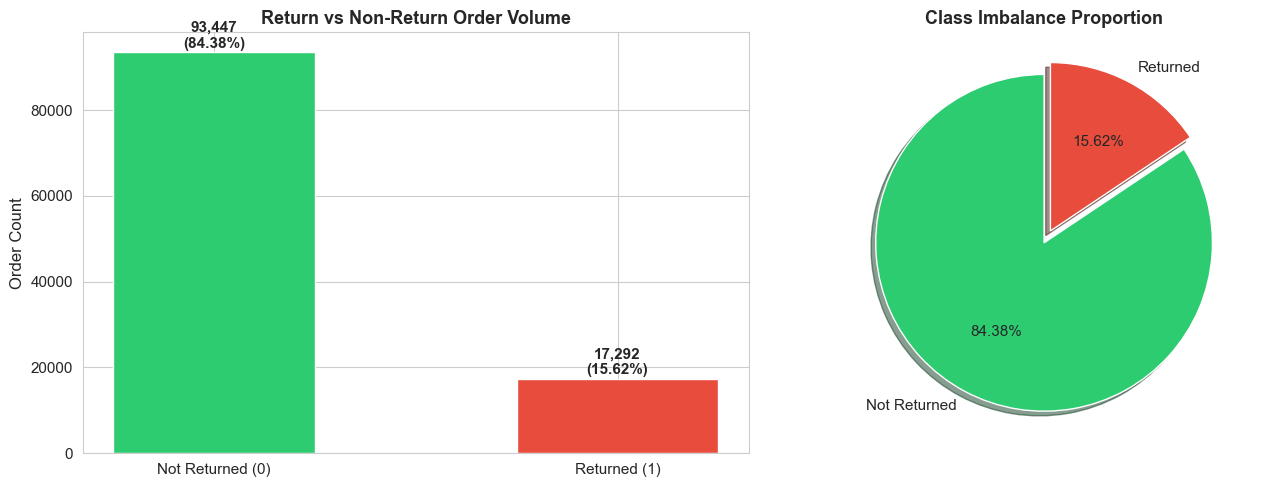

Target Summary:
 - Non-Returned Orders (0) : 93,447 (84.38%)
 - Returned Orders (1)     : 17,292 (15.62%)
 - Imbalance Ratio         : 1:5.40


In [4]:
# --- Cell 2: Target Variable Distribution & Class Imbalance ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Bar Chart
counts = df['is_returned'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Not Returned (0)', 'Returned (1)'], counts.values, color=colors, width=0.5)
axes[0].set_title('Return vs Non-Return Order Volume', fontweight='bold')
axes[0].set_ylabel('Order Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + (df.shape[0] * 0.01), f'{v:,}\n({v/len(df)*100:.2f}%)', ha='center', fontweight='bold')

# 2. Pie Chart
axes[1].pie(counts.values, labels=['Not Returned', 'Returned'], 
            colors=colors, autopct='%1.2f%%', startangle=90, explode=(0, 0.08), shadow=True)
axes[1].set_title('Class Imbalance Proportion', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

imbalance_ratio = counts[0] / counts[1]
print(f"Target Summary:")
print(f" - Non-Returned Orders (0) : {counts[0]:,} ({counts[0]/len(df)*100:.2f}%)")
print(f" - Returned Orders (1)     : {counts[1]:,} ({counts[1]/len(df)*100:.2f}%)")
print(f" - Imbalance Ratio         : 1:{imbalance_ratio:.2f}")

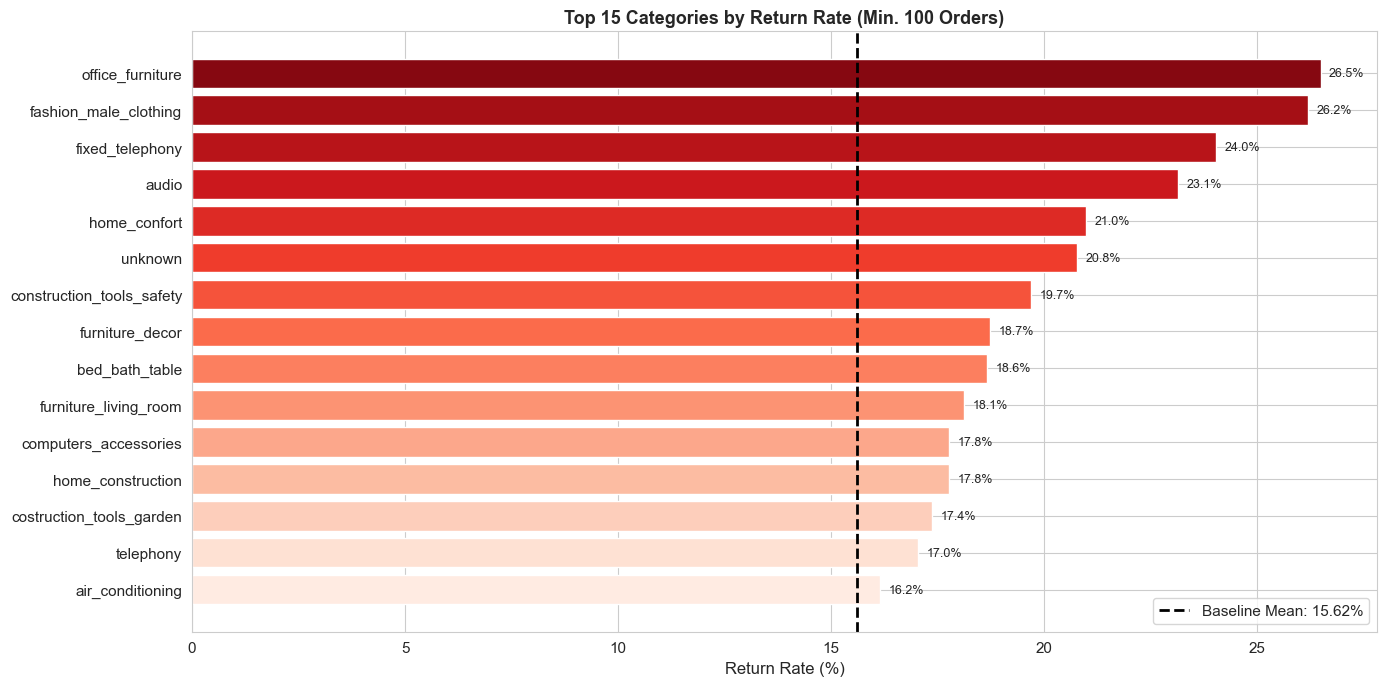

In [5]:
# --- Cell 3: Return Rate by Top Product Categories ---
cat_returns = df.groupby('product_category_name_english').agg(
    total_orders=('is_returned', 'count'),
    returns=('is_returned', 'sum'),
    return_rate=('is_returned', 'mean')
).sort_values('return_rate', ascending=False)

# Filter top categories with a minimum order threshold for statistical validity
min_orders = 100
cat_returns_filtered = cat_returns[cat_returns['total_orders'] >= min_orders].head(15)

fig, ax = plt.subplots(figsize=(14, 7))
palette = sns.color_palette('Reds_r', len(cat_returns_filtered))
bars = ax.barh(cat_returns_filtered.index, cat_returns_filtered['return_rate'] * 100, color=palette)

# Highlight overall mean return rate
overall_avg = df['is_returned'].mean() * 100
ax.axvline(x=overall_avg, color='black', linestyle='--', linewidth=2, label=f'Baseline Mean: {overall_avg:.2f}%')

ax.set_xlabel('Return Rate (%)')
ax.set_title('Top 15 Categories by Return Rate (Min. 100 Orders)', fontweight='bold')
ax.invert_yaxis()  # Highest return rate at the top
ax.legend(loc='lower right')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.2, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_category_return_rate.png', dpi=300, bbox_inches='tight')
plt.show()

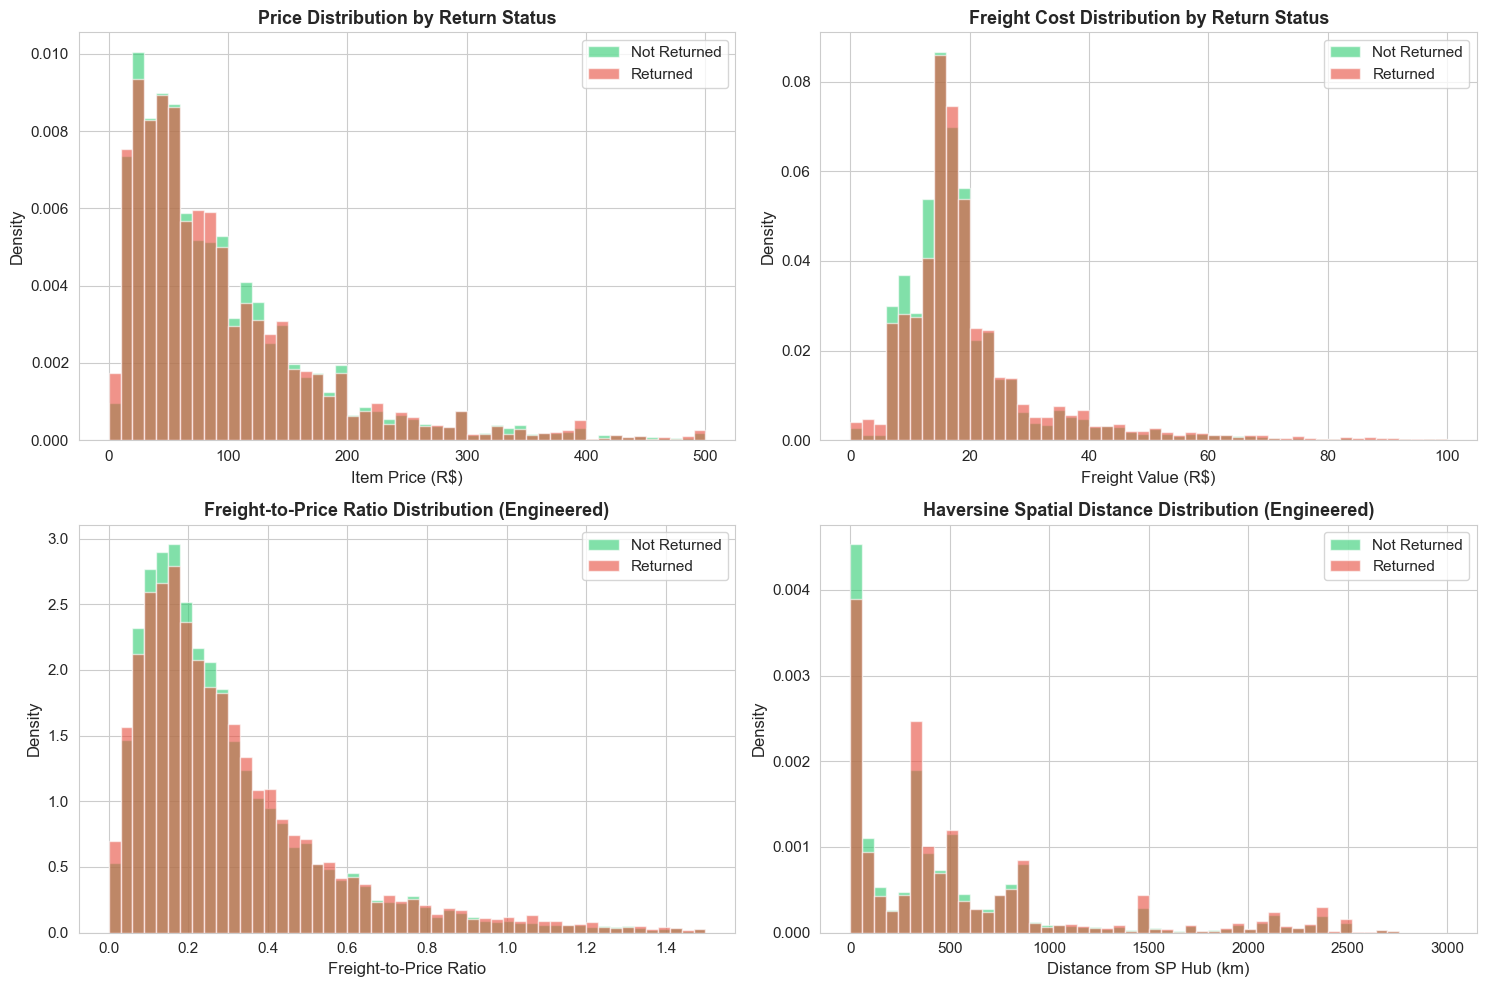

In [10]:
# --- Cell 4: Logistics, Pricing & Engineered Ratio Distributions ---
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Price Distribution
for status, color, label in [(0, '#2ecc71', 'Not Returned'), (1, '#e74c3c', 'Returned')]:
    subset = df[df['is_returned'] == status]
    axes[0, 0].hist(subset['price'], bins=50, range=(0, 500), alpha=0.6, color=color, label=label, density=True)
axes[0, 0].set_xlabel('Item Price (R$)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title('Price Distribution by Return Status', fontweight='bold')
axes[0, 0].legend()

# 2. Freight Value Distribution
for status, color, label in [(0, '#2ecc71', 'Not Returned'), (1, '#e74c3c', 'Returned')]:
    subset = df[df['is_returned'] == status]
    axes[0, 1].hist(subset['freight_value'], bins=50, range=(0, 100), alpha=0.6, color=color, label=label, density=True)
axes[0, 1].set_xlabel('Freight Value (R$)')
axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title('Freight Cost Distribution by Return Status', fontweight='bold')
axes[0, 1].legend()

# 3. Freight-to-Price Ratio (Engineered)
for status, color, label in [(0, '#2ecc71', 'Not Returned'), (1, '#e74c3c', 'Returned')]:
    subset = df[df['is_returned'] == status]
    axes[1, 0].hist(subset['freight_to_price_ratio'], bins=50, range=(0, 1.5), alpha=0.6, color=color, label=label, density=True)
axes[1, 0].set_xlabel('Freight-to-Price Ratio')
axes[1, 0].set_ylabel('Density')
axes[1, 0].set_title('Freight-to-Price Ratio Distribution (Engineered)', fontweight='bold')
axes[1, 0].legend()

# 4. Haversine Spatial Distance (Engineered)
for status, color, label in [(0, '#2ecc71', 'Not Returned'), (1, '#e74c3c', 'Returned')]:
    subset = df[df['is_returned'] == status]
    axes[1, 1].hist(subset['haversine_distance_km'], bins=50, range=(0, 3000), alpha=0.6, color=color, label=label, density=True)
axes[1, 1].set_xlabel('Distance from SP Hub (km)')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Haversine Spatial Distance Distribution (Engineered)', fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('eda_cost_spatial_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

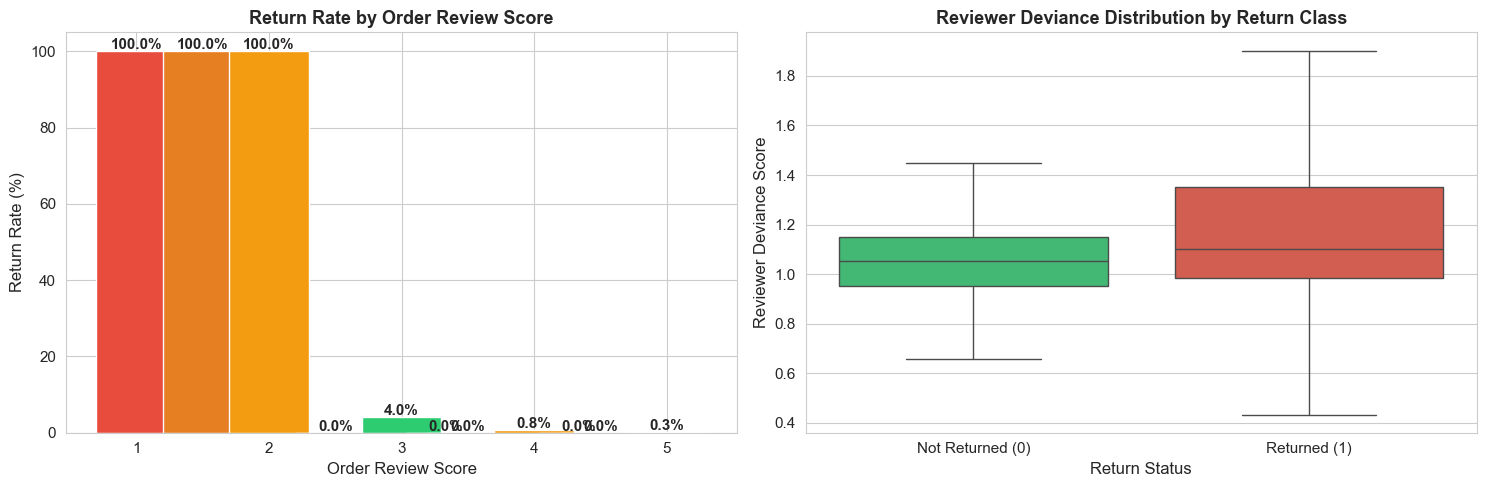

In [11]:
# --- Cell 5: Review Scores & Reviewer Deviance Behavior ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Return Rate by Customer Review Score
review_returns = df.groupby('review_score')['is_returned'].mean() * 100
axes[0].bar(review_returns.index, review_returns.values, 
            color=['#e74c3c', '#e67e22', '#f39c12', '#27ae60', '#2ecc71'], width=0.6)
axes[0].set_xlabel('Order Review Score')
axes[0].set_ylabel('Return Rate (%)')
axes[0].set_title('Return Rate by Order Review Score', fontweight='bold')
for i, (idx, val) in enumerate(review_returns.items()):
    axes[0].text(idx, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')

# 2. Reviewer Deviance Score Boxplot by Return Status
sns.boxplot(x='is_returned', y='reviewer_deviance_score', data=df, ax=axes[1], palette=['#2ecc71', '#e74c3c'], showfliers=False)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Not Returned (0)', 'Returned (1)'])
axes[1].set_xlabel('Return Status')
axes[1].set_ylabel('Reviewer Deviance Score')
axes[1].set_title('Reviewer Deviance Distribution by Return Class', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_review_deviance_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

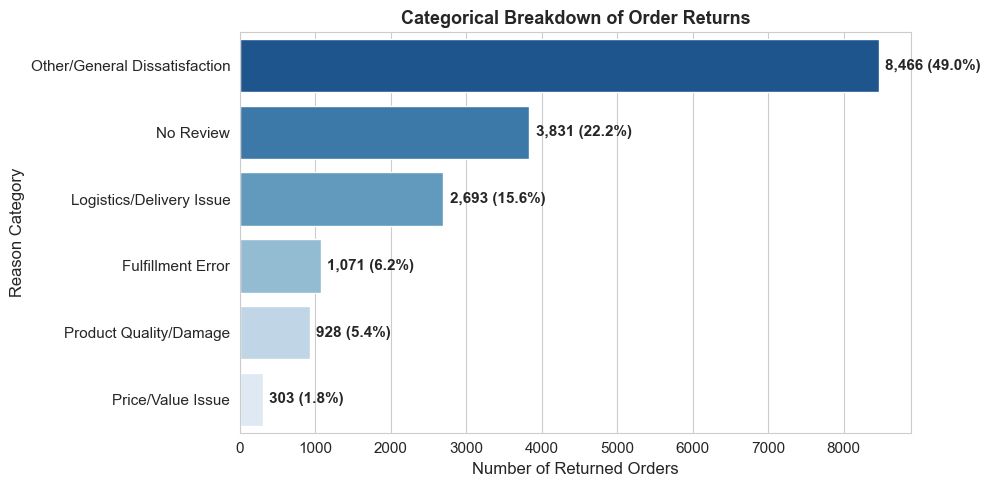

In [12]:
# --- Cell 6: Return Reason Analysis ---
fig, ax = plt.subplots(figsize=(10, 5))

# Isolate return reasons for returned orders
returned_df = df[df['is_returned'] == 1]
reason_counts = returned_df['return_reason'].value_counts()

sns.barplot(x=reason_counts.values, y=reason_counts.index, ax=ax, palette='Blues_r')
ax.set_xlabel('Number of Returned Orders')
ax.set_ylabel('Reason Category')
ax.set_title('Categorical Breakdown of Order Returns', fontweight='bold')

for i, v in enumerate(reason_counts.values):
    ax.text(v + (max(reason_counts.values) * 0.01), i, f'{v:,} ({v/len(returned_df)*100:.1f}%)', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_return_reasons.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# --- Cell 7: Feature Correlation Analysis with Target ---
# Select relevant numerical and engineered features
numeric_cols = [
    'price', 'freight_value', 'product_weight_g', 'product_volume_cm3',
    'customer_return_rate', 'customer_order_count', 'customer_avg_review',
    'category_return_rate', 'product_return_rate', 'haversine_distance_km',
    'reviewer_deviance_score', 'freight_to_price_ratio', 'density_g_cm3', 'is_returned'
]

# Filter existing columns
valid_cols = [col for col in numeric_cols if col in df.columns]
corr_matrix = df[valid_cols].corr()

# Plot Top Correlations with Target
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Matrix (Including Step 4 Engineered Ratios)', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Print Top Predictors
target_corr = corr_matrix['is_returned'].drop('is_returned').sort_values(ascending=False)
print("=====================================================================")
print("TOP PREDICTIVE CORRELATIONS WITH TARGET (is_returned)")
print("=====================================================================")
print(target_corr)